In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))


In [2]:
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from src.dataset import get_dataloaders
from src.utils import train_model, print_train_times, plot_curves
from src.models.lstm import BaselineLSTM
from src.models.reservoirs import RandomLSM, StructuredLSNN


In [3]:
# Setup device and seed for reproducibility

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Running on {DEVICE}")

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED) 

Running on mps


In [4]:
train_loader, test_loader = get_dataloaders('../data/processed', batch_size=64, processed=True)

In [5]:
MODEL_LOGS = []
results = []
# =========================================================
# Run LSTM Baseline
# =========================================================

print("\n=== RUNNING LSTM BASELINE ===")
model = BaselineLSTM()
model, hist = train_model(model, train_loader, test_loader, device=DEVICE, epochs=30, lr=0.001)

results.append({
    "Model": "LSTM (Baseline)",
    "Accuracy": hist['test_acc'][-1]
})
MODEL_LOGS.append({"name": "BaselineLSTM", "history": hist})

# =========================================================
# Tune Random LSM
# =========================================================

print("\n=== TUNING RANDOM LSM ===")
scales = [10.0, 50.0]
betas = [0.9, 0.95]
lrs = [0.001, 0.005]

for scale in scales:
    for beta in betas:
        for lr in lrs:
            print(f"Running LSM | Scale: {scale} | Beta: {beta} | LR: {lr}")
            
            model = RandomLSM(beta=beta, input_scale=scale)
            model, hist = train_model(model, train_loader, test_loader, device=DEVICE, epochs=30, lr=lr)
            
            results.append({
                "Model": f"LSM (Random)-s-{scale}-b-{beta}-lr-{lr}",
                "Params": f"Scale={scale}, Beta={beta} | LR: {lr}",
                "Accuracy": hist['test_acc'][-1]
            })

            MODEL_LOGS.append({"name": f"RandomLSM-s-{scale}-b-{beta}-lr-{lr}", "history": hist})

# =========================================================
# Tune Structured LSNN
# =========================================================

print("\n=== TUNING STRUCTURED LSNN ===")
orders = [6, 12, 24] # d
gains = [1.0, 4.0]   # p

for d in orders:
    for gain in gains:
        for lr in lrs:
            print(f"Running LSNN | Order(d): {d} | Gain: {gain} | LR: {lr}")
            
            model = StructuredLSNN(d=d, gain=gain)
            model, hist = train_model(model, train_loader, test_loader, device=DEVICE, epochs=30, lr=lr)
            
            results.append({
                "Model": "LSNN (Structured)",
                "Params": f"d={d}, Gain={gain} | LR: {lr}",
                "Accuracy": hist['test_acc'][-1]
            })
            MODEL_LOGS.append({"name": f"StructuredLSNN-d-{d}-g-{gain}-lr-{lr}", "history": hist})

# =========================================================
# FINAL REPORT
# =========================================================
grid_search_df = pd.DataFrame(results)
print("\nFINAL COMPARISON:")
print(grid_search_df.sort_values(by="Accuracy", ascending=False))
grid_search_df.to_csv('grid_search_df.csv', index=False)


=== RUNNING LSTM BASELINE ===


Training:   0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

...

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]


FINAL COMPARISON:
                                  Model   Accuracy  \
0                       LSTM (Baseline)  97.244444   
18                    LSNN (Structured)  97.066667   
14                    LSNN (Structured)  93.844444   
20                    LSNN (Structured)  92.222222   
16                    LSNN (Structured)  90.955556   
17                    LSNN (Structured)  90.177778   
2    LSM (Random)-s-10.0-b-0.9-lr-0.005  89.955556   
10                    LSNN (Structured)  89.755556   
12                    LSNN (Structured)  89.444444   
4   LSM (Random)-s-10.0-b-0.95-lr-0.005  89.333333   
13                    LSNN (Structured)  89.155556   
6    LSM (Random)-s-50.0-b-0.9-lr-0.005  87.488889   
15                    LSNN (Structured)  87.444444   
5    LSM (Random)-s-50.0-b-0.9-lr-0.001  87.177778   
8   LSM (Random)-s-50.0-b-0.95-lr-0.005  87.111111   
7   LSM (Random)-s-50.0-b-0.95-lr-0.001  86.866667   
19                    LSNN (Structured)  86.577778   
3   LSM (

In [13]:
grid_search_df = pd.DataFrame(results)
print("\nFINAL COMPARISON:")
grid_search_df_sorted = grid_search_df.sort_values(by="Accuracy", ascending=False)
grid_search_df_sorted.to_csv('grid_search_df_sorted.csv', index=False)
print(grid_search_df_sorted)




FINAL COMPARISON:
                                  Model   Accuracy  \
0                       LSTM (Baseline)  97.244444   
18                    LSNN (Structured)  97.066667   
14                    LSNN (Structured)  93.844444   
20                    LSNN (Structured)  92.222222   
16                    LSNN (Structured)  90.955556   
17                    LSNN (Structured)  90.177778   
2    LSM (Random)-s-10.0-b-0.9-lr-0.005  89.955556   
10                    LSNN (Structured)  89.755556   
12                    LSNN (Structured)  89.444444   
4   LSM (Random)-s-10.0-b-0.95-lr-0.005  89.333333   
13                    LSNN (Structured)  89.155556   
6    LSM (Random)-s-50.0-b-0.9-lr-0.005  87.488889   
15                    LSNN (Structured)  87.444444   
5    LSM (Random)-s-50.0-b-0.9-lr-0.001  87.177778   
8   LSM (Random)-s-50.0-b-0.95-lr-0.005  87.111111   
7   LSM (Random)-s-50.0-b-0.95-lr-0.001  86.866667   
19                    LSNN (Structured)  86.577778   
3   LSM (

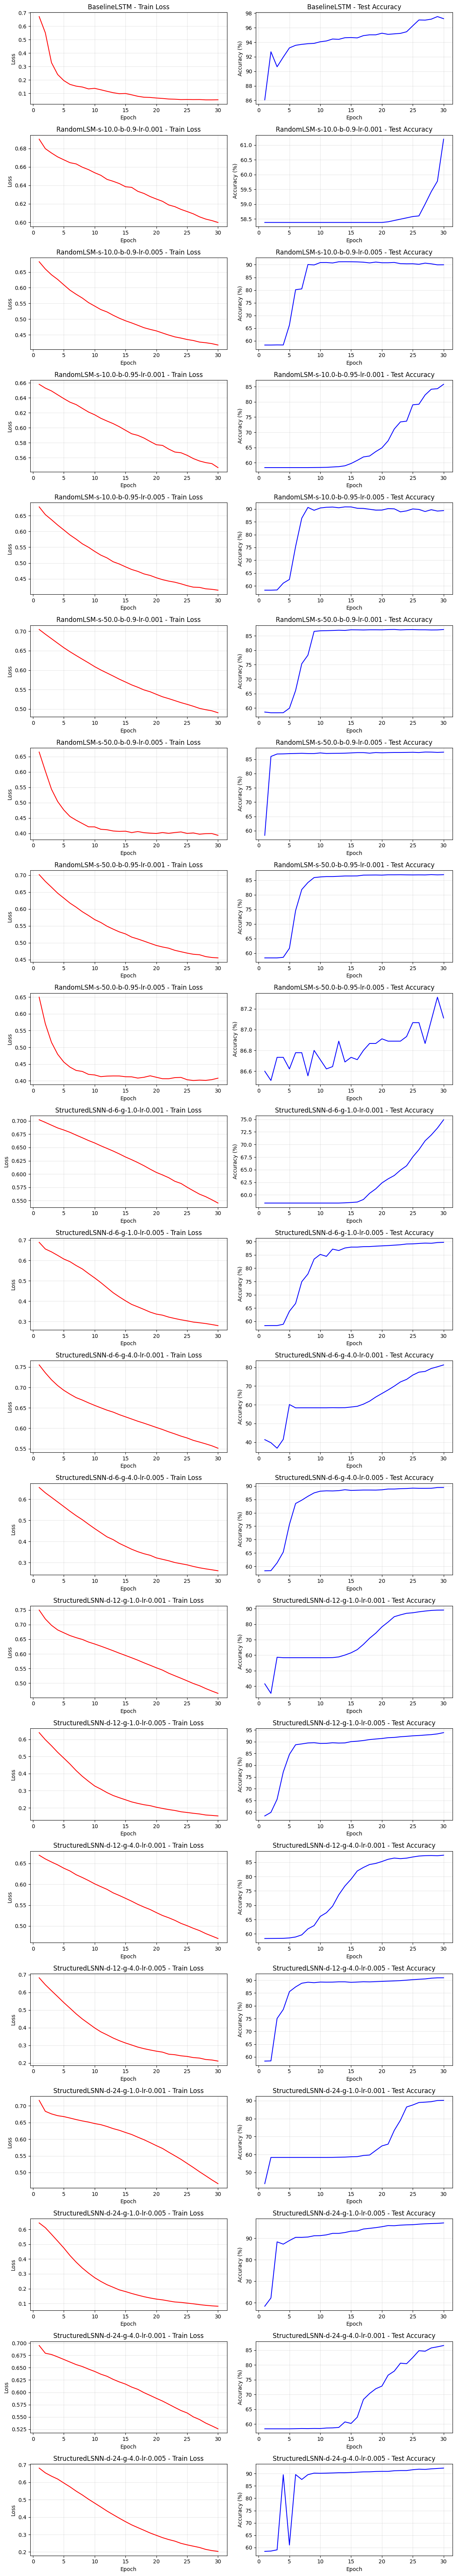

In [7]:
plot_curves(MODEL_LOGS)

In [8]:
print_train_times(MODEL_LOGS)

BaselineLSTM: 18.92365002632141 s
RandomLSM-s-10.0-b-0.9-lr-0.001: 84.62508702278137 s
RandomLSM-s-10.0-b-0.9-lr-0.005: 80.09306812286377 s
RandomLSM-s-10.0-b-0.95-lr-0.001: 79.04811596870422 s
RandomLSM-s-10.0-b-0.95-lr-0.005: 78.73449516296387 s
RandomLSM-s-50.0-b-0.9-lr-0.001: 78.70460176467896 s
RandomLSM-s-50.0-b-0.9-lr-0.005: 78.46496987342834 s
RandomLSM-s-50.0-b-0.95-lr-0.001: 87.44788098335266 s
RandomLSM-s-50.0-b-0.95-lr-0.005: 83.98675298690796 s
StructuredLSNN-d-6-g-1.0-lr-0.001: 112.97549223899841 s
StructuredLSNN-d-6-g-1.0-lr-0.005: 106.63373517990112 s
StructuredLSNN-d-6-g-4.0-lr-0.001: 108.27595686912537 s
StructuredLSNN-d-6-g-4.0-lr-0.005: 106.79001092910767 s
StructuredLSNN-d-12-g-1.0-lr-0.001: 103.16329073905945 s
StructuredLSNN-d-12-g-1.0-lr-0.005: 100.67788791656494 s
StructuredLSNN-d-12-g-4.0-lr-0.001: 99.62424492835999 s
StructuredLSNN-d-12-g-4.0-lr-0.005: 107.66776609420776 s
StructuredLSNN-d-24-g-1.0-lr-0.001: 104.16169500350952 s
StructuredLSNN-d-24-g-1.0-lr-0

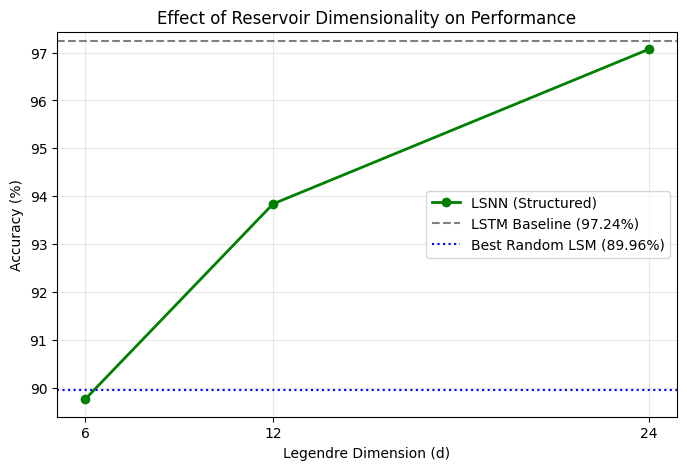

In [9]:
d_values = [6, 12, 24]
accuracies = [89.76, 93.84, 97.07]
lstm_acc = 97.24
lsm_acc = 89.96

plt.figure(figsize=(8, 5))
plt.plot(d_values, accuracies, marker='o', linestyle='-', color='green', linewidth=2, label='LSNN (Structured)')
plt.axhline(y=lstm_acc, color='gray', linestyle='--', label=f'LSTM Baseline ({lstm_acc}%)')
plt.axhline(y=lsm_acc, color='blue', linestyle=':', label=f'Best Random LSM ({lsm_acc}%)')

plt.xlabel('Legendre Dimension (d)')
plt.ylabel('Accuracy (%)')
plt.title('Effect of Reservoir Dimensionality on Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks([6, 12, 24])
plt.show()